<a href="https://colab.research.google.com/github/nuralilider-cmyk/online-shop-intention-cluster/blob/main/online_shop_intention_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
csv='/content/online_shoppers_intention.csv'
df=pd.read_csv(csv)

Revenue
False    10422
True      1908
Name: count, dtype: int64


Text(0, 0.5, 'amount of purchase')

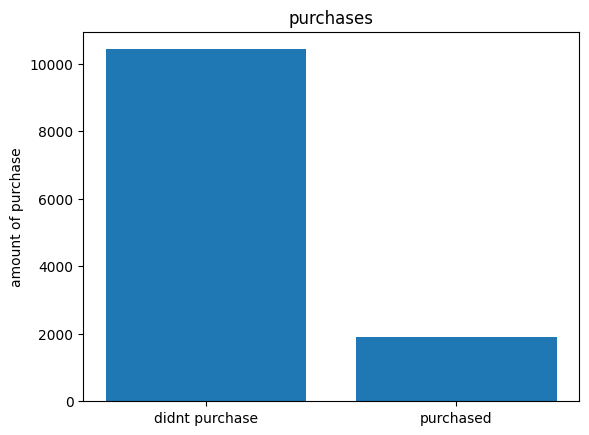

In [4]:
count=df['Revenue'].value_counts()
print(count)
plt.bar( ['didnt purchase', 'purchased'], [count[False],count[True]])
plt.title('purchases')
plt.ylabel('amount of purchase')

In [6]:
numeric_features=[
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

categorical_features=[
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'Month',
    'VisitorType',
    'Weekend'
]
X=df[numeric_features+categorical_features]
y=df['Revenue']

In [7]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder( handle_unknown='ignore'), categorical_features)
    ])
X_processed=preprocessor.fit_transform(X)

In [8]:
inertias=[]
silhouette_scores=[]

K_values=range(2,9)

for k in K_values:

    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels=model.fit_predict(X_processed)

    inertias.append(model.inertia_)

    silhouette_scores.append(
        silhouette_score(
            X_processed,
            labels
        )
    )

In [9]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(
    X_processed
)

df['Cluster']=clusters

In [10]:
cluster_sizes=df['Cluster'].value_counts().sort_index()

print(cluster_sizes)

Cluster
0     950
1    1503
2    8907
3     970
Name: count, dtype: int64


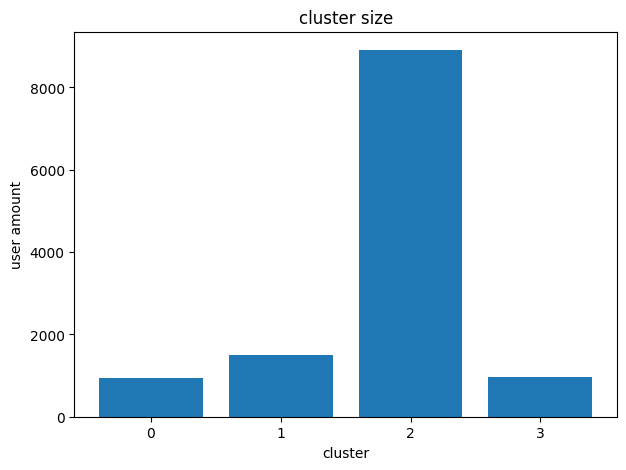

In [18]:
plt.figure(figsize=(7,5))

plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes.values
)

plt.xlabel('cluster')
plt.ylabel('user amount')
plt.title('cluster size')

plt.show()

In [ ]:
cluster_purchase=df.groupby('Cluster')['Revenue'].mean()*100

print('cluster purchase percentage')

for cluster,value in cluster_purchase.items():

    print(
        'Cluster',
        cluster,
        ':',
        round(value,2),
        '%'
    )

Purchase percentage by cluster:
Cluster 0 : 6.32 %
Cluster 1 : 28.61 %
Cluster 2 : 15.85 %
Cluster 3 : 0.62 %


In [ ]:
purchase_table=pd.crosstab(
    df['Cluster'],
    df['Revenue']
)

display(purchase_table)

Revenue,False,True
Cluster,,
0,890,60
1,1073,430
2,7495,1412
3,964,6


In [ ]:
cluster_profile=df.groupby('Cluster')[numeric_features].mean()
display(cluster_profile.round(2))

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Cluster,,,,,,,,,,
0,1.11,32.17,0.23,10.02,27.11,921.50,0.02,0.05,2.19,0.68
1,7.43,314.00,2.62,225.28,99.62,3956.79,0.01,0.02,9.57,0.01
2,1.83,55.32,0.23,8.63,23.95,883.25,0.01,0.03,6.30,0.00
3,0.04,1.32,0.01,0.07,2.53,42.96,0.17,0.18,0.00,0.06


In [11]:
numeric_features_no_pagevalues=[
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'SpecialDay'
]

X_no_pagevalues=df[
    numeric_features_no_pagevalues+
    categorical_features
]

In [15]:
preprocessor_no_pagevalues=ColumnTransformer(
    transformers=[('num', StandardScaler(),numeric_features_no_pagevalues),
        ('cat', OneHotEncoder( handle_unknown='ignore'),categorical_features)])

X_no_pagevalues_processed=preprocessor_no_pagevalues.fit_transform(
    X_no_pagevalues
)

In [16]:
kmeans_no_pagevalues=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_no_pagevalues=kmeans_no_pagevalues.fit_predict(
    X_no_pagevalues_processed
)

df['Cluster_No_PageValues']=clusters_no_pagevalues

In [17]:
comparison=pd.DataFrame({
    'with page values':
        df.groupby('Cluster')['Revenue'].mean()*100,

    'no page values':
        df.groupby('Cluster_No_PageValues')['Revenue'].mean()*100
})

display(comparison.round(2))

,with page values,no page values
0,6.32,6.32
1,28.61,0.62
2,15.85,28.43
3,0.62,15.89
